In [1]:
#easter egg :p
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spy = yf.download("SPY", start="1993-01-01")


prices = spy["Close"]
daily_returns = prices.pct_change()


#cumprod returns cumulative_product
#always vectorize

cumulative_returns = (1 + daily_returns).cumprod() - 1
    #  (100% + x).cumprod()


#spy.head()
daily_returns.head()
cumulative_returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
1993-01-29,NaN
1993-02-01,0.007112
1993-02-02,0.009246
1993-02-03,0.019914
1993-02-04,0.024182


In [5]:
rolling_peak = prices.cummax()
drawdown = prices / rolling_peak - 1
drawdown.head()
print(drawdown.min())

equity_curve = (1 + daily_returns).cumprod() 

Ticker
SPY   -0.551895
dtype: float64


<Figure size 1200x600 with 0 Axes>

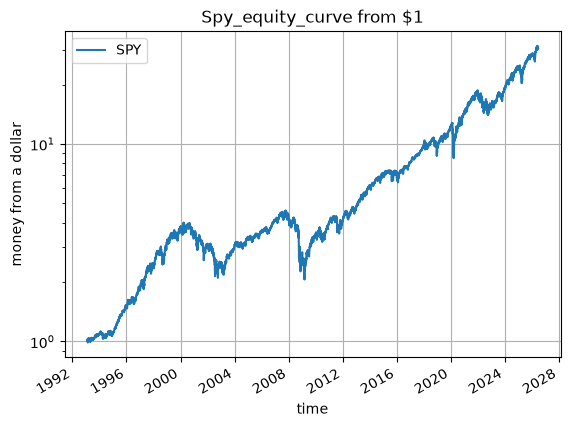

In [10]:
plt.figure(figsize = (12,6))
equity_curve.plot(label = "spy equity curve")
plt.title("Spy_equity_curve from $1")
plt.xlabel("time")
plt.ylabel("money from a dollar")
plt.grid(True)
plt.yscale("log")
plt.legend()

<Axes: xlabel='Date'>

<Figure size 640x480 with 0 Axes>

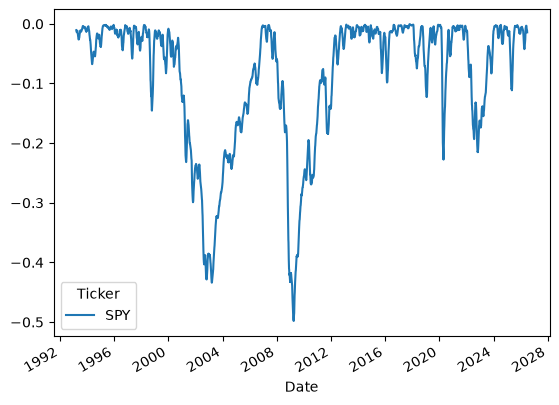

In [12]:
# plt.figure()
# drawdown.plot(label = "drawdown")
# plt.title("Drawdown Plot")
# plt.xlabel("time")
# plt.ylabel("curr drop from max")
# plt.grid(True)
# plt.legend()

#interesting plot: to make smooth, using rolling(window = x)


smoothed_drawdown = drawdown.rolling(window=30).mean()

plt.figure()
smoothed_drawdown.plot(label = "smoothed_darwodnw0")

In [14]:
total_return = equity_curve.iloc[-1]

years = len(daily_returns.dropna()) / 252

cagr = total_return ** (1 / years) - 1


#standard deviation of yearly returns
annualized_volatility = np.sqrt(252) * daily_returns.std()

sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

max_drawdown = drawdown.min()

In [16]:
summary_stats = pd.Series({
    "CAGR": cagr,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
})

summary_stats

CAGR                     Ticker
SPY    0.107826
Name: 2026-06-25 00:00:...
Annualized Volatility                Ticker
SPY    0.185757
dtype: float64
Sharpe Ratio                         Ticker
SPY    0.644288
dtype: float64
Max Drawdown                         Ticker
SPY   -0.551895
dtype: float64
dtype: object